In [ ]:
from google.colab import drive

drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
#Loads the MNIST dataset, downsamples the images to 14x14
transform = transforms.Compose([
    transforms.Resize((14, 14)), #resizes to 14x14
    transforms.ToTensor(),
])

#Load MNIST dataset and apply transformations
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9.91M/9.91M [00:00<00:00, 17.7MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28.9k/28.9k [00:00<00:00, 500kB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1.65M/1.65M [00:00<00:00, 4.46MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4.54k/4.54k [00:00<00:00, 3.67MB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



In [3]:
labels_map = {
    0: "0",
    1: "1",
    2: "2",
    3: "3",
    4: "4",
    5: "5",
    6: "6",
    7: "7",
    8: "8",
    9: "9",
}

#Display a batch of images
def show_images(train_dataset, cols, rows):
  figure = plt.figure(figsize=(8, 8))

  for i in range(1, cols * rows + 1):
      sample_idx = torch.randint(len(train_dataset), size=(1,)).item()
      img, label = train_dataset[sample_idx]
      figure.add_subplot(rows, cols, i)
      plt.title(labels_map[label])
      plt.axis("off")
      plt.imshow(img.squeeze(), cmap="gray")

  plt.show()

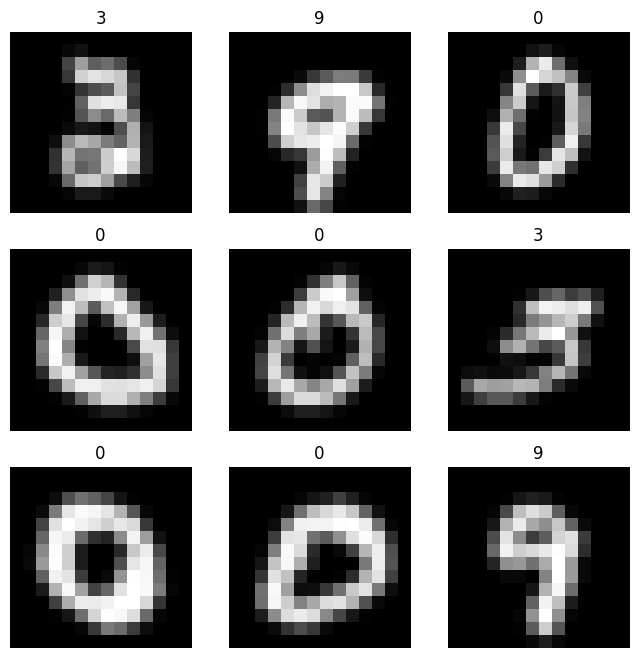

In [4]:
show_images(train_dataset, 3, 3)

In [5]:
class ConvLayer(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=1):
    super(ConvLayer, self).__init__()

    #initialize weights with a normal distribution
    self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=padding)

    #use ReLU activation
    self.relu = nn.ReLU()

    self.pool = nn.AvgPool2d(kernel_size=2, stride=2) #average pooling to downsize the image from 14x14 to 7x7

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.conv.weight)

  def forward(self, x):
    x = self.conv(x)
    x = self.relu(x)
    x = self.pool(x)
    return x

#This sublayer is implemented by CustomLayer and simulates a chip core containing up to 128 units. To handle 256 units it splits its input into 2 128-element vectors and uses multiple learnable weight matrices to simulate negative weights. It outputs a 128-element weighted sum vector passed through an activation function
class SubLayer(nn.Module):
  def __init__(self):
    super(SubLayer, self).__init__()

    #create 2 128x128 learnable weight matrices(values updated automatically in training) (simulating a a left and right half of a full weight matrix to simulate negative weights)
    self.weight1 = nn.Parameter(torch.abs(torch.randn(128, 128))) #torch.abs ensures there aren't negative weight values(chip constraint)
    self.weight2 = nn.Parameter(torch.abs(torch.randn(128, 128)))
    self.bias = nn.Parameter(torch.tensor(0.0)) #learnable bias term for the weighted sums
    self.sigmoid = nn.Sigmoid()

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.weight1)
    nn.init.xavier_uniform_(self.weight2)

  def forward(self, x):
    #ensure weight matrices remain non-negative(to satsify chip constraints)
    self.weight1 = nn.Parameter(torch.clamp(self.weight1, min=0))
    self.weight2 = nn.Parameter(torch.clamp(self.weight2, min=0))

    #split 256 element input into 2 128 element vectors
    x1 = x[:, :128]
    x2 = x[:, 128:]

    #perform matrix multiplication on the weight matrices to form weighted sum inputs
    x1_weighted = torch.mm(x1, self.weight1)
    x2_weighted = torch.mm(x2, self.weight2)

    #subtract the two weighted sum matrices to form 1 weighted sum matrix of size batch_size by 128(one weighted sum vector of 128 elements for each input), add the bias term to each weighted sum
    out = x1_weighted - x2_weighted + self.bias

    #pass the output through a sigmoid activation function
    out = self.sigmoid(out)

    return out

#This layer follows the flatten layer of the neural network and simulates 2 chip cores. It recieves a vector of 294 elements consisting of all the pooled feature maps flattened. It implements two fully-connected sublayers and outputs two vectors of 128 elements each
class CustomLayer(nn.Module):
  def __init__(self):
    super(CustomLayer, self).__init__()

    #create two sublayers, each with 128 units
    self.subLayer1 = SubLayer()
    self.subLayer2 = SubLayer()

  def forward(self, x):
    #divide the 294-element vector into 2 256-element overlapping vectors
    x1 = x[:, :256]
    x2 = x[:, 38:]

    #pass each vector to a sub-layer
    out1 = self.subLayer1(x1)
    out2 = self.subLayer2(x2)

    return out1, out2

#This layer takes in the two vectors of 128 elements outputted from CustomLayer, matrix multiplies each by multiple learnable weight matrices of size 128x10 and subtracts the two resulting vectors to constrain the size to 10, corresponding to 10 MNIST classes.
class OutputLayer(nn.Module):
  def __init__(self):
    super(OutputLayer, self).__init__()

    self.weight1 = nn.Parameter(torch.abs(torch.randn(128, 10))) #create 2 128x10 learnable weight matrices
    self.weight2 = nn.Parameter(torch.abs(torch.randn(128, 10)))
    self.bias = nn.Parameter(torch.tensor(0.0)) #learnable bias term for the weighted sums
    self.softmax = nn.Softmax(dim=1) #softmax performed so the values in every row(all classes) probabilities add to 1

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.weight1)
    nn.init.xavier_uniform_(self.weight2)


  def forward(self, x1, x2): #receives two inputs of 128 elements each, 1 from each of the previous sublayers
    #ensure weight matrices remain non-negative(to satisfy chip constraints)
    self.weight1 = nn.Parameter(torch.clamp(self.weight1, min=0))
    self.weight2 = nn.Parameter(torch.clamp(self.weight2, min=0))

    #perform matrix multiplication on the weight matrices to form weighted sum inputs
    x1_weighted = torch.mm(x1, self.weight1)
    x2_weighted = torch.mm(x2, self.weight2)

    #subtract the two weighted sum matrices to form 1 weighted sum matrix of size batch_size by 10(one weighted sum vector of 128 elements for each MNIST class), add the bias term to each weighted sum
    out = x1_weighted - x2_weighted + self.bias

    #apply softmax function
    out = self.softmax(out)

    return out




#Overall Architecture
class EIC_Architecture(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size, stride, padding):
    super(EIC_Architecture, self).__init__()
    self.conv1 = ConvLayer(in_channels, out_channels, kernel_size, stride, padding)
    self.flatten = nn.Flatten() #Flattens the 6 7x7 average pooled feature maps into 1 contigous vector of 294 elements
    self.customLayer = CustomLayer()
    self.outputLayer = OutputLayer()

  def forward(self, x):
    x = self.conv1(x)  #Apply convolutional layer, output = [64, 6, 7, 7] (batch size, out_channels, pooled size)
    x = self.flatten(x)  #Flatten the feature maps, output = [64, 294] (batch size, out_channels * pooled feature map size)
    out1, out2 = self.customLayer(x) #get two 128-element output vectors
    out = self.outputLayer(out1, out2) #Takes the two 128-element vectors, applies weights to them and produces a vector of 10 elements to correspond to MNIST's 10 classes
    return out

In [6]:
#testing
x = torch.randn(64,294)
x1 = x[:,:256]
x1.size()
x2 = x[:, 38:]
x2.size()
out = x2-x1
out.size()
print(torch.sigmoid(out))

tensor([[0.2853, 0.9312, 0.6871,  ..., 0.8195, 0.7905, 0.1000],
        [0.6991, 0.0554, 0.8018,  ..., 0.1736, 0.5431, 0.1311],
        [0.9383, 0.3468, 0.9732,  ..., 0.8363, 0.5405, 0.6376],
        ...,
        [0.7245, 0.0527, 0.2440,  ..., 0.3253, 0.9419, 0.5970],
        [0.1688, 0.5194, 0.2917,  ..., 0.4407, 0.5681, 0.7476],
        [0.9166, 0.7662, 0.5752,  ..., 0.5714, 0.7799, 0.1902]])


In [7]:
#more testing
x = torch.randn(3,3) #the first dimension(rows) represent batches, the second dimension(columns) represent the actual classes
softmax0 = nn.Softmax(dim=0)
softmax1 = nn.Softmax(dim=1)
probabilities0 = softmax0(x)
probabilities1 = softmax1(x)

print(probabilities0) #wrong, each column adds to 1, not row
print(probabilities1) #right, each row adds to 1, not column

tensor([[0.5149, 0.2714, 0.7020],
        [0.3180, 0.5472, 0.0851],
        [0.1670, 0.1814, 0.2129]])
tensor([[0.1155, 0.0790, 0.8056],
        [0.2173, 0.4852, 0.2975],
        [0.1120, 0.1578, 0.7303]])


In [8]:
model = EIC_Architecture(in_channels=1, out_channels=6, kernel_size=(3,3), stride=1, padding=1)
print(model)
#in_channels: MNIST is grayscale, so each pixel has one value
#out_channels: equal to the number of kernels, which is 6
#kernel_size: size of each kernel
#stride: how much a kernel shifts across the image each step
#padding: number of layers of 0s added around the image. To preserve the image size(zero padding), this number is equal to (kernel size(3) - 1)/2 = 1

EIC_Architecture(
  (conv1): ConvLayer(
    (conv): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU()
    (pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (customLayer): CustomLayer(
    (subLayer1): SubLayer(
      (sigmoid): Sigmoid()
    )
    (subLayer2): SubLayer(
      (sigmoid): Sigmoid()
    )
  )
  (outputLayer): OutputLayer(
    (softmax): Softmax(dim=1)
  )
)


In [9]:
#test output shape
for images, labels in train_loader:
    output = model(images)
    print(f"Output shape: {output.shape}")
    break  # Run only one batch

#looks good, 64 images(1 batch) and there are 10 classes

Output shape: torch.Size([64, 10])


In [10]:
def create_adam_optimizer(model, learning_rate=0.01):
  return torch.optim.Adam(model.parameters(), lr=learning_rate)

In [23]:
learning_rate = 0.00008
loss_fn = nn.CrossEntropyLoss()
optimizer = create_adam_optimizer(model, learning_rate)

In [12]:
#training model
def train_model(model, train_loader, optimzer, epochs=5, batch_size=64, loss_fn=nn.CrossEntropyLoss()):
  #Setup device
  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
  model.to(device)

  for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, data in enumerate(train_loader, 0):
      #get the inputs; data is a list of [inputs, labels]
      inputs, labels = data

      #zero the parameter gradients
      optimizer.zero_grad()

      #update output, loss function optimzer
      outputs = model(inputs)
      loss = loss_fn(outputs, labels)
      loss.backward()
      optimizer.step()

      #get model's prediction
      _, predicted = torch.max(outputs, 1)

      # print statistics
      running_loss += loss.item()
      if i % 2000 == 1999:    # print every 2000 mini-batches
          print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
          running_loss = 0.0

      correct += (predicted == labels).sum().item()
      total += labels.size(0)


    # Print statistics after each epoch
    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")

  print("Training complete")

In [24]:
epochs = 10
train_model(model, train_loader, optimizer, loss_fn=loss_fn, epochs=epochs)

Epoch 1/10, Loss: 2.2889, Accuracy: 18.26%
Epoch 2/10, Loss: 2.2888, Accuracy: 18.33%
Epoch 3/10, Loss: 2.2887, Accuracy: 18.37%
Epoch 4/10, Loss: 2.2887, Accuracy: 18.42%
Epoch 5/10, Loss: 2.2886, Accuracy: 18.47%
Epoch 6/10, Loss: 2.2885, Accuracy: 18.52%
Epoch 7/10, Loss: 2.2885, Accuracy: 18.57%
Epoch 8/10, Loss: 2.2884, Accuracy: 18.61%
Epoch 9/10, Loss: 2.2883, Accuracy: 18.66%
Epoch 10/10, Loss: 2.2882, Accuracy: 18.71%
Training complete


In [ ]:
#save model
torch.save(model.state_dict(), '/content/gdrive/MyDrive/UCSD Neuromorphic Computing Internship: Prof. Gert Cauwenberghs/Code/EIC_Part2_lr' + str(learning_rate) + '_ep' + str(epochs) + '.pth')

In [ ]:
def evaluate_model(model, test_loader):
    model.eval()  # Set model to evaluation mode
    correct = 0
    total = 0

    for data in test_loader:
        inputs, labels = data

        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)  # Get the predicted class
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    accuracy = 100 * correct / total
    return accuracy

In [ ]:
#test the model on the MNIST testing data split
evaluate_model(model, test_loader)

26.79